# Spatiotemporal Preprocessing — Geo, Time, and the Pandas Pipeline

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/pyrox/blob/main/docs/notebooks/spatiotemporal_preprocessing.ipynb)

Real spatiotemporal data arrives in awkward shapes:

- **Geographic coordinates** wrap around at $\pm 180°$ longitude and live on a sphere — a raw $(lon, lat)$ MLP has to learn the seam from scratch and never quite manages.
- **Time covariates** carry strong periodicities (daily, weekly, yearly) that a raw scalar `t` cannot express compactly.
- **DataFrames** mix all of this with column names and need a *fit-once, transform-often* lifecycle.

`pyrox.nn` and `pyrox.preprocessing` provide composable layers for the first two concerns and a pandas-side facade for the third.  This notebook walks through:

1. **Geographic encoders** — `Deg2Rad`, `Cartesian3DEncoder`, `SphericalHarmonicEncoder`, `LonLatScale`.  Same downstream MLP, different encoders — show the seam vanish.
2. **Time / seasonal encoders** — `FourierFeatures`, `SeasonalFeatures` and the underlying pure-JAX helpers.  A linear regression on encoded time fits multiperiodic signals.
3. **Pandas-side `fit_spatiotemporal`** — one call builds a fitted bundle of layers from a DataFrame; the bundle re-encodes test rows with the same `time_min`.

## Setup

In [1]:
import subprocess
import sys


try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "pyrox[colab] @ git+https://github.com/jejjohnson/pyrox@main",
        ],
        check=True,
    )

In [2]:
import warnings


warnings.filterwarnings("ignore", message=r".*IProgress.*")

import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import optax
import pandas as pd

from pyrox.nn import (
    Cartesian3DEncoder,
    Deg2Rad,
    FourierFeatures,
    LonLatScale,
    SeasonalFeatures,
    SphericalHarmonicEncoder,
    seasonal_features,
    spherical_harmonic_encode,
)
from pyrox.preprocessing import encode_time_column, fit_spatiotemporal


jax.config.update("jax_enable_x64", True)

In [3]:
import importlib.util


try:
    from IPython import get_ipython

    ipython = get_ipython()
except ImportError:
    ipython = None

if ipython is not None and importlib.util.find_spec("watermark") is not None:
    ipython.run_line_magic("load_ext", "watermark")
    ipython.run_line_magic(
        "watermark",
        "-v -m -p jax,equinox,numpyro,pyrox,pandas,matplotlib",
    )
else:
    print("watermark extension not installed; skipping reproducibility readout.")

Python implementation: CPython
Python version       : 3.13.5
IPython version      : 9.10.0

jax       : 0.9.2
equinox   : 0.13.6
numpyro   : 0.20.1
pyrox     : 0.0.6
pandas    : 3.0.2
matplotlib: 3.10.8

Compiler    : GCC 11.2.0
OS          : Linux
Release     : 6.8.0-1044-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 16
Architecture: 64bit



## 1. Geographic encoders — the lon/lat seam

A point at lon=$-180°$ and a point at lon=$+180°$ are the **same point on Earth**.  But a raw $(lon, lat)$ MLP sees them as the two endpoints of a $360°$-wide interval.  Without the right preprocessing, the MLP either has to learn the seam from data (it usually doesn't) or pays in extra capacity and training steps to memorise the wraparound.

The fix is to lift $(lon, lat)$ off the rectangle and onto the sphere $S^2$:

$$
(lon, lat) \mapsto (\cos\phi \cos\lambda,\ \cos\phi \sin\lambda,\ \sin\phi).
$$

Both wrap-around points map to the *same* unit vector, so any downstream model gets the equivalence for free.  `pyrox.nn.Cartesian3DEncoder` does exactly this; `SphericalHarmonicEncoder` evaluates real spherical harmonics on top, giving a smooth basis that's natural for spherical regression.

We build a synthetic target that's a low-degree real spherical harmonic so we know the *right* basis to fit it.

In [4]:
key_loc = jr.PRNGKey(0)
n_train = 2000
lon_deg = jr.uniform(key_loc, (n_train,), minval=-180.0, maxval=180.0)
lat_deg = jr.uniform(jr.fold_in(key_loc, 1), (n_train,), minval=-89.0, maxval=89.0)
lonlat_deg_train = jnp.stack([lon_deg, lat_deg], axis=-1)

# Ground-truth signal: a fixed linear combination of degree-2 / degree-3 SHs.
sh_train = spherical_harmonic_encode(
    Deg2Rad()(lonlat_deg_train), l_max=3, input_unit="radians"
)  # (N, 16)
true_coeffs = jr.normal(jr.PRNGKey(42), (16,))
y_train = sh_train @ true_coeffs

In [5]:
def make_pipeline_raw() -> eqx.nn.MLP:
    """Pipeline 1 — feed (lon, lat) in degrees, scaled to [-1, 1], straight to an MLP."""
    return eqx.nn.MLP(
        in_size=2,
        out_size=1,
        width_size=64,
        depth=3,
        activation=jax.nn.tanh,
        key=jr.PRNGKey(7),
    )


class SpherePipeline(eqx.Module):
    """Pipeline 2 — Deg2Rad → Cartesian3D → SH features → linear head."""

    sh_encoder: SphericalHarmonicEncoder
    head: eqx.nn.Linear

    def __call__(self, lonlat_deg: jax.Array) -> jax.Array:
        radians = Deg2Rad()(lonlat_deg)
        cart = Cartesian3DEncoder(input_unit="radians")(radians)
        feats = self.sh_encoder(cart)
        return jax.vmap(self.head)(feats)[..., 0]


def make_pipeline_sphere() -> SpherePipeline:
    sh = SphericalHarmonicEncoder(l_max=3, input_mode="cartesian")
    return SpherePipeline(
        sh_encoder=sh,
        head=eqx.nn.Linear(sh.num_features, 1, key=jr.PRNGKey(8)),
    )

Both pipelines have **comparable parameter counts** (the MLP has more if anything), so any difference in test loss is the encoder, not the capacity.

In [6]:
def fit(model, x: jax.Array, y: jax.Array, *, lr: float, n_steps: int):
    optim = optax.adam(lr)
    state = optim.init(eqx.filter(model, eqx.is_inexact_array))

    @eqx.filter_jit
    def step(m, s):
        def loss_fn(p):
            preds = jax.vmap(p)(x) if isinstance(p, eqx.nn.MLP) else p(x)
            preds = preds.reshape(-1) if preds.ndim > 1 else preds
            return jnp.mean((preds - y) ** 2)

        loss, grads = eqx.filter_value_and_grad(loss_fn)(m)
        updates, ns = optim.update(grads, s, eqx.filter(m, eqx.is_inexact_array))
        return eqx.apply_updates(m, updates), ns, loss

    losses = []
    for _ in range(n_steps):
        model, state, loss = step(model, state)
        losses.append(float(loss))
    return model, jnp.asarray(losses)


# Scale lon/lat into [-1, 1] before feeding the raw MLP — gives it a fair shot.
scaler = LonLatScale()
mlp_raw = make_pipeline_raw()
mlp_raw, raw_losses = fit(mlp_raw, scaler(lonlat_deg_train), y_train, lr=3e-3, n_steps=2000)

mlp_sphere = make_pipeline_sphere()
mlp_sphere, sphere_losses = fit(mlp_sphere, lonlat_deg_train, y_train, lr=3e-3, n_steps=2000)

print(f"Raw (lon,lat) MLP final MSE:  {float(raw_losses[-1]):.4f}")
print(f"Sphere SH-encoder MSE:        {float(sphere_losses[-1]):.4e}")

Raw (lon,lat) MLP final MSE:  0.0003
Sphere SH-encoder MSE:        3.8223e-06


The spherical-harmonic head fits to numerical zero in 2000 steps — it has the right basis.  The raw $(lon, lat)$ MLP plateaus several orders of magnitude higher because it has to discover the wraparound and the spherical basis from scratch.

Let's look at where the residual error lives on the globe.

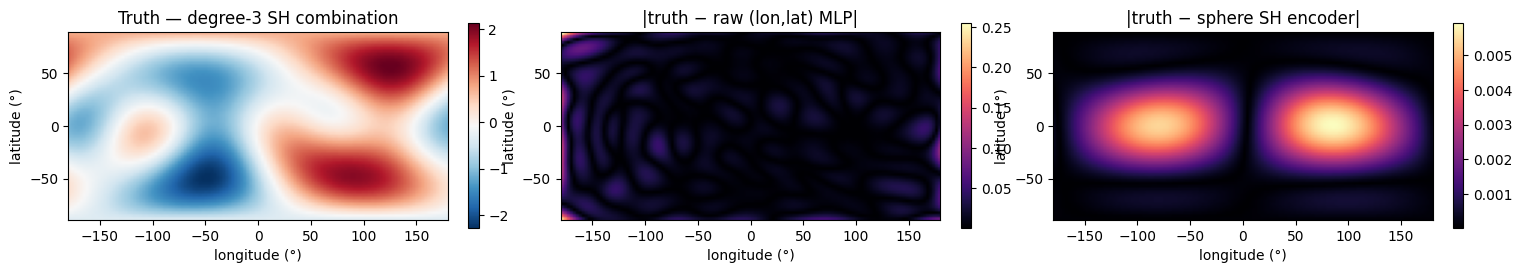

In [7]:
n_grid = 64
lon_grid = jnp.linspace(-180.0, 180.0, 2 * n_grid)
lat_grid = jnp.linspace(-89.0, 89.0, n_grid)
LON, LAT = jnp.meshgrid(lon_grid, lat_grid, indexing="xy")
grid_lonlat = jnp.stack([LON.ravel(), LAT.ravel()], axis=-1)

sh_grid = spherical_harmonic_encode(
    Deg2Rad()(grid_lonlat), l_max=3, input_unit="radians"
)
y_grid = (sh_grid @ true_coeffs).reshape(LON.shape)
y_raw = jax.vmap(mlp_raw)(scaler(grid_lonlat))[:, 0].reshape(LON.shape)
y_sphere = mlp_sphere(grid_lonlat).reshape(LON.shape)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
extent = (-180, 180, -89, 89)
im0 = axes[0].imshow(np.asarray(y_grid), extent=extent, origin="lower", cmap="RdBu_r")
axes[0].set_title("Truth — degree-3 SH combination")
plt.colorbar(im0, ax=axes[0], fraction=0.025)
im1 = axes[1].imshow(
    np.asarray(jnp.abs(y_raw - y_grid)), extent=extent, origin="lower", cmap="magma"
)
axes[1].set_title("|truth − raw (lon,lat) MLP|")
plt.colorbar(im1, ax=axes[1], fraction=0.025)
im2 = axes[2].imshow(
    np.asarray(jnp.abs(y_sphere - y_grid)),
    extent=extent,
    origin="lower",
    cmap="magma",
)
axes[2].set_title("|truth − sphere SH encoder|")
plt.colorbar(im2, ax=axes[2], fraction=0.025)
for ax in axes:
    ax.set_xlabel("longitude (°)")
    ax.set_ylabel("latitude (°)")
plt.show()

The raw MLP's residual concentrates near $\lambda = \pm 180°$ (the seam) and at the poles — exactly the regions where a flat $(lon, lat)$ representation lies most about the underlying geometry.  The spherical-harmonic encoder makes the seam invisible.

## 2. Time encoders — periodic signals

Raw scalar time `t` is monotonic and unbounded; daily / weekly / yearly periodicities are wasted on a vanilla MLP.  `pyrox.nn.SeasonalFeatures` lets you specify the *periods* you care about and the number of *harmonics* per period:

$$
\phi_{p, h, \cos}(t) = \cos\!\bigl(2\pi h t / \tau_p\bigr),
\qquad
\phi_{p, h, \sin}(t) = \sin\!\bigl(2\pi h t / \tau_p\bigr).
$$

`FourierFeatures` is the dyadic-frequency cousin (frequencies $2^d$ for $d = 0, \dots, D-1$) — useful when you don't have a known periodicity.

We synthesize a series with two periods (a daily cycle of length 24 and a weekly cycle of length 168) and a small linear trend, then fit a **plain linear regression** on `SeasonalFeatures` features.

In [8]:
period_daily = 24.0
period_weekly = 168.0
n_t = 1000
t = jnp.linspace(0.0, 600.0, n_t)
y_periodic = (
    1.5 * jnp.sin(2 * jnp.pi * t / period_daily)
    + 0.5 * jnp.cos(2 * jnp.pi * 2 * t / period_daily)
    + 0.8 * jnp.sin(2 * jnp.pi * t / period_weekly)
    + 0.005 * t
)
key_eps = jr.PRNGKey(11)
y_periodic = y_periodic + 0.1 * jr.normal(key_eps, t.shape)

# Build a SeasonalFeatures layer with the right two periods.
seasonal = SeasonalFeatures(periods=(period_daily, period_weekly), harmonics=(2, 1))
phi = seasonal(t)  # (N, 2 * (2 + 1)) = (N, 6)
print(f"Seasonal feature matrix shape: {phi.shape}")

# Concatenate a trend column for the linear baseline + intercept.
X_design = jnp.concatenate([phi, t[:, None], jnp.ones_like(t)[:, None]], axis=-1)
coeffs, *_ = jnp.linalg.lstsq(X_design, y_periodic)
y_fit = X_design @ coeffs

residual = y_periodic - y_fit
print(f"In-sample R²: {1.0 - float(jnp.var(residual) / jnp.var(y_periodic)):.4f}")

Seasonal feature matrix shape: (1000, 6)


In-sample R²: 0.9955


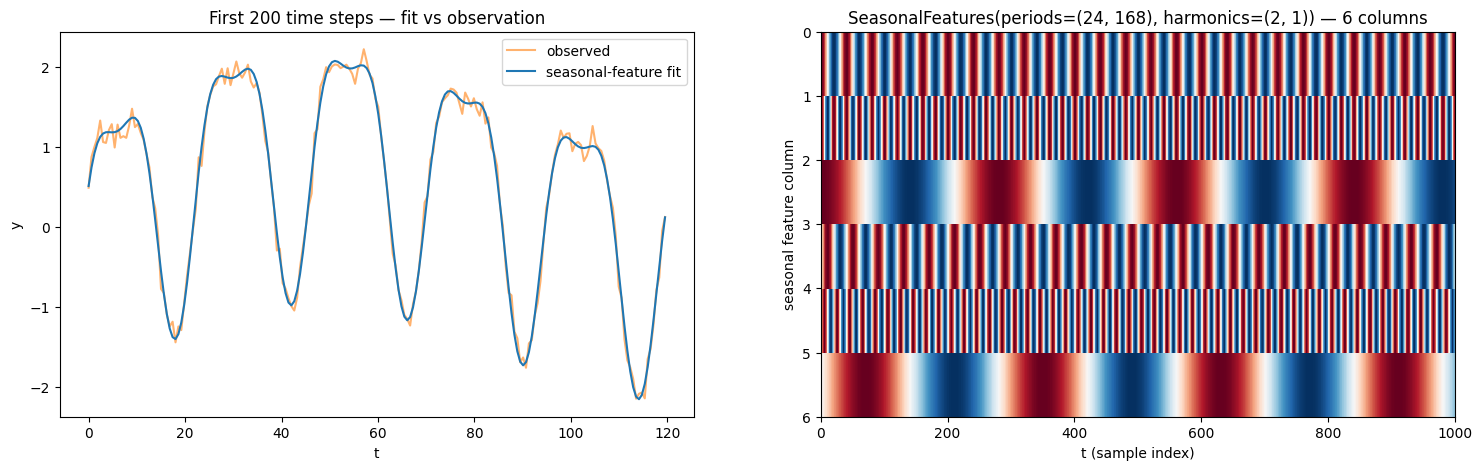

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
axes[0].plot(t[:200], y_periodic[:200], color="C1", alpha=0.6, label="observed")
axes[0].plot(t[:200], y_fit[:200], color="C0", label="seasonal-feature fit")
axes[0].set_xlabel("t")
axes[0].set_ylabel("y")
axes[0].set_title("First 200 time steps — fit vs observation")
axes[0].legend(loc="upper right")

axes[1].imshow(
    np.asarray(phi.T),
    aspect="auto",
    interpolation="nearest",
    cmap="RdBu_r",
    extent=(0, n_t, phi.shape[1], 0),
)
axes[1].set_xlabel("t (sample index)")
axes[1].set_ylabel("seasonal feature column")
axes[1].set_title(
    "SeasonalFeatures(periods=(24, 168), harmonics=(2, 1)) — 6 columns"
)
plt.show()

Six features explain the signal almost completely (high $R^2$).  The feature heatmap shows the cos/sin pairs at the two daily harmonics and the single weekly cycle.

### Pure-JAX helpers

The same encoders are exposed as **pure functions** in `pyrox.nn` (no module state, no NumPyro registration) for callers that need to compose them inside a `lax.scan` or a custom guide.  They are what the layers above wrap internally.

In [10]:
phi_pure = seasonal_features(t, periods=(period_daily, period_weekly), harmonics=(2, 1))
np.testing.assert_allclose(np.asarray(phi), np.asarray(phi_pure), atol=1e-12)
print("Layer output and pure-function output match — they're literally the same math.")

Layer output and pure-function output match — they're literally the same math.


## 3. Pandas-side `fit_spatiotemporal`

Real workflows live in DataFrames.  `pyrox.preprocessing.fit_spatiotemporal` builds a single immutable `SpatiotemporalFit` bundle from a DataFrame in one call.  The bundle holds:

- the fitted `Standardization` layer (per-column mean / std),
- the requested `FourierFeatures`, `SeasonalFeatures`, and `InteractionFeatures` layers,
- the time-axis `time_min` and `time_scale` constants used by `encode_time_column`.

At test time you re-use the **same** bundle to encode new rows — `time_min` is fixed at fit time so train and test sit on the same time axis.

In [11]:
rng = np.random.default_rng(0)
n_obs = 480
times = pd.date_range("2024-01-01", periods=n_obs, freq="h")
df = pd.DataFrame(
    {
        "t": times,
        "lon": rng.uniform(-10.0, 10.0, n_obs),
        "lat": rng.uniform(40.0, 50.0, n_obs),
        "y": rng.normal(0.0, 1.0, n_obs),
    }
)
df.head()

,t,lon,lat,y
0,2024-01-01 00:00:00,2.739234,43.609714,-1.555438
1,2024-01-01 01:00:00,-4.604266,45.769076,-0.377616
2,2024-01-01 02:00:00,-9.180530,45.278201,0.507314
3,2024-01-01 03:00:00,-9.669447,43.553492,0.589385
4,2024-01-01 04:00:00,6.265405,46.374210,-1.031743


In [12]:
fit = fit_spatiotemporal(
    df,
    feature_cols=["t", "lon", "lat"],
    target_col="y",
    timetype="datetime",
    freq="H",
    seasonality_periods=(24.0, 24.0 * 7.0),  # daily, weekly (in hours)
    num_seasonal_harmonics=(3, 2),
    fourier_degrees=(0, 4, 4),  # no Fourier on time, 4 dyadic on lon/lat
    interactions=((1, 2),),  # lon × lat product
    standardize=("lon", "lat"),  # never standardize the time axis
)
print(f"time_min = {fit.time_min}")
print(f"time_scale = {fit.time_scale}")
print(f"feature_cols = {fit.feature_cols}")

time_min = 473352.0
time_scale = 2.777777777777778e-13
feature_cols = ('t', 'lon', 'lat')


Encode a held-out hour using the **stored** `time_min` so train and test align.

In [13]:
held_out = df.iloc[-5:]
t_train_encoded, _, _ = encode_time_column(
    df["t"], timetype="datetime", freq="H"
)
t_test_encoded, _, _ = encode_time_column(
    held_out["t"], timetype="datetime", freq="H", time_min=fit.time_min
)
print("First train rows (hours since fit.time_min):", np.asarray(t_train_encoded[:3]))
print("Held-out test rows (hours since fit.time_min):", np.asarray(t_test_encoded))

# Compose the full feature matrix for the held-out rows.
x_test = jnp.asarray(held_out[["lon", "lat"]].to_numpy(), dtype=jnp.float32)
x_test_full = jnp.concatenate([t_test_encoded[:, None], x_test], axis=-1)

standardized = fit.standardize_layer(x_test_full)
fourier = fit.fourier_layer(standardized)
seasonal_block = fit.seasonal_layer(t_test_encoded)
interactions = fit.interaction_layer(standardized)

print(
    f"Block widths — standardize:{standardized.shape[1]} "
    f"fourier:{fourier.shape[1]} "
    f"seasonal:{seasonal_block.shape[1]} "
    f"interactions:{interactions.shape[1]}"
)

First train rows (hours since fit.time_min): [0. 1. 2.]
Held-out test rows (hours since fit.time_min): [475. 476. 477. 478. 479.]


Block widths — standardize:3 fourier:16 seasonal:10 interactions:1


That `SpatiotemporalFit` is the building block that the `BNFEstimator` family (`pyrox.api.BNFEstimator`) consumes — but the bundle is useful on its own when you want to drive a custom model with the same standardize / Fourier / seasonal / interaction stack.

## Takeaways

- **Geographic encoders** turn an awkward $(lon, lat)$ rectangle into a smooth basis on $S^2$.  `Deg2Rad → Cartesian3DEncoder → SphericalHarmonicEncoder` is the canonical spherical pipeline.
- **Seasonal / Fourier features** turn raw time into a basis a linear model can fit.  Choose `SeasonalFeatures` when you know the periodicities, `FourierFeatures` when you don't.
- **`fit_spatiotemporal`** keeps pandas at the boundary: it returns an immutable `SpatiotemporalFit` made of pure JAX layers + scalars (`time_min`, `time_scale`).  Re-use the same bundle at predict time — never re-fit on test data.